<a href="https://colab.research.google.com/github/TerteryanTatev/Machine-Learning-Algorithms/blob/main/Decision-Tree-Classifier/decision_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from graphviz import Digraph

In [ ]:
data = pd.DataFrame({
    "X1":[0,1,0,0,1,1,1,1],
    "X2":[0,0,1,1,1,0,1,1],
    "X3":[1,1,0,1,1,1,0,0],
    "X4":[0,1,1,0,1,0,1,0],
    "Y": [0,1,1,0,1,0,1,1]
})

In [ ]:
def gini_xer(df, xer):

    n = len(df)

    gini = 0

    for value in [0,1]:

        subset = df[df[xer] == value]

        px = len(subset) / n

        if len(subset) == 0:
            continue

        py0 = np.mean(subset["Y"] == 0)
        py1 = np.mean(subset["Y"] == 1)

        gini += px * py0 * py1

    return gini

In [ ]:
def best_xer(df, xer):

    ginis = {}

    for f in xer:
        ginis[f] = gini_xer(df,f)

    print("\nGini values")
    for k,v in ginis.items():
        print(k,"=",round(v,4))

    return min(ginis, key=ginis.get)

In [ ]:
def build_tree(df, xer):

    classes = df["Y"].unique()
    if len(classes) == 1:
        return classes[0]

    if len(xer) == 0:
        return df["Y"].mode()[0]

    best = best_xer(df, xer)
    tree = {best:{}}
    nor = [f for f in xer if f != best]

    for value in [0,1]:

        ob = df[df[best] == value]

        if len(ob) == 0:
            tree[best][value] = df["Y"].mode()[0]

        else:
            tree[best][value] = build_tree(ob, nor)

    return tree

In [ ]:
xer = ["X1","X2","X3","X4"]

tree = build_tree(data,xer)

print("\nDecision Tree")
print(tree)


Gini values
X1 = 0.1833
X2 = 0.1833
X3 = 0.15
X4 = 0.0938

Gini values
X1 = 0.125
X2 = 0.125
X3 = 0.0

Decision Tree
{'X4': {0: {'X3': {0: np.int64(1), 1: np.int64(0)}}, 1: np.int64(1)}}


In [ ]:
def draw_tree(tree, graph=None, parent=None, edge_label="", node_id_prefix=""):

    if graph is None:
        graph = Digraph()

    if not isinstance(tree, dict):
        # leaf node
        node_id = node_id_prefix + "_leaf_" + str(tree)
        graph.node(node_id, str(tree))
        if parent:
            graph.edge(parent, node_id, label=edge_label)
        return graph

    feature = list(tree.keys())[0]
    node_id = node_id_prefix + "_" + feature

    graph.node(node_id, feature)
    if parent:
        graph.edge(parent, node_id, label=edge_label)

    for value, subtree in tree[feature].items():
        # path-ը տալիս է յուրահատուկ id
        child_id_prefix = node_id_prefix + "_" + feature + str(value)
        draw_tree(subtree, graph, node_id, str(value), child_id_prefix)

    return graph

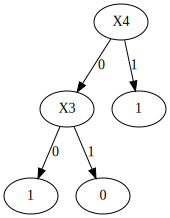

In [ ]:
graph = draw_tree(tree)

graph

In [ ]:
def g(tree, n):
    if not isinstance(tree, dict):

        return tree

    xer = list(tree.keys())[0]
    xer_value = n[xer]

    subtree = tree[xer][xer_value]


    return g(subtree, n)

In [ ]:
new_data = {
    "X1": 1,
    "X2": 0,
    "X3": 0,
    'X4': 0
}

result = g(tree, new_data)
print("Y:", result)

Y: 1
